# isotropic Heisenberg / hardware-efficient RYA — campaign analysis (Figs 12, 13, 14 (appendix))

Analysis notebook for the frozen 2025 seed-sweep campaign: Heisenberg chain
(n=5), depths 1–10, noise levels $p = \{1,5\}\times10^{-\{3..6\}}$, COBYLA.
Produces the paper's Figs 12, 13, 14 (appendix).

| | |
|---|---|
| **input** | `../results/heisenberg_n5/rya/Results/*.pkl` (copied campaign pickles, git-ignored) |
| **regenerate the data** | `data_generation/gen_rya_myqlm_{noiseless,noisy}.ipynb` (myQLM env) |
| **run** | from `notebooks/` (relative `../results` paths); headless: `./run_all.sh` |


### Imports

In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

### standard values

In [2]:
#gate_ctt = np.array([165, 315, 465, 615, 765, 915, 1065, 1215, 1365, 1515], dtype = int)

In [3]:
gate_ctt = np.array([5 + 25 * i for i in range(1, 11, 1)])  # Heisenberg RYA: N_g(ct) = 5 + 25*ct

In [4]:
#gate_ctt = np.array([100* i for i in range(1, 11, 1)])

In [5]:
gate_ctt

array([ 30,  55,  80, 105, 130, 155, 180, 205, 230, 255])

In [6]:
g_en5 = -7.711545013271975

In [7]:
nseeds = 50

In [8]:
dep = np.arange(1, 11, 1, dtype = int)

In [9]:
base_expo = [[1,6], [5,6], [1,5], [5,5], [1,4], [5,4], [1,3]]

In [10]:
eps = [b[0]*(10**(-b[1])) for b in base_expo]

In [11]:
perr = []
exp_off = []
for yt in range(len(eps)):
    p_er = np.array(1 - (1-eps[yt])**gate_ctt)
    perr.append(perr)
    exp_off.append(1 - p_er)

### noiseless data

In [12]:
maxiter = 25000
with open('../../results/heisenberg_n5/rya/Results/noiseless_COBY_50_seeds.pkl', 'rb') as file:
    ress = pickle.load(file)

In [13]:
# Build yruns and ylist keyed by depth
yruns = {}
ylist = {}
for gt in dep:
    yran, ylis = [], []
    for ht in range(nseeds):
        result = ress['%s'%ht][gt - 1]
        trace  = eval(result.meta_data['optimization_trace'])
        vv     = result.value
        trace += [vv] * (maxiter - len(trace))   # pad to maxiter
        yran.append(trace)
        ylis.append(vv)
    yruns['%s'%gt] = yran
    ylist['%s'%gt] = ylis

In [14]:
# Compute statistics
res_data_idm, res_data_ids = [], []
val_list_idm, val_list_ids = [], []

for gt in dep:
    yran = np.array(yruns['%s'%gt])
    ylis = np.array(ylist['%s'%gt])
    mean_y  = np.mean(yran, axis=0)
    std_y   = np.std(yran,  axis=0)
    val     = np.mean(ylis, axis=0)
    val_std = np.std(ylis,  axis=0)
    res_data_idm.append(mean_y)
    res_data_ids.append(std_y)
    val_list_idm.append(val)
    val_list_ids.append(val_std)

with open('Results/noiseless_COBY_rand_runs.pkl', 'rb') as file:
    yruns = pickle.load(file)

with open('Results/noiseless_COBY_rand_list.pkl', 'rb') as file:
    ylist = pickle.load(file)

res_data_idm = []
res_data_ids = []
val_list_idm = []
val_list_ids = []

for gt in dep:
    yran = np.array(yruns['%s'%gt])
    ylis = np.array(ylist['%s'%gt])
    # Compute mean and standard deviation across runs
    mean_y = np.mean(yran, axis=0)
    std_y = np.std(yran, axis=0)
    val = np.mean(ylis, axis=0)
    val_std = np.std(ylis, axis=0)
    res_data_idm.append(mean_y)
    res_data_ids.append(std_y)
    val_list_idm.append(val)
    val_list_ids.append(val_std)

In [15]:
len(yran)

50

### noisy data

In [16]:
noisy_data_mean = {}
noisy_data_std = {}
noisy_data_val_m = {}
noisy_data_val_s = {}
for gt in range(len(base_expo)):
    #with open('global_noisy_seeds_gates/noisy-%s_%s.pkl'%(base_expo[gt][0], base_expo[gt][1]), 'rb') as file:
    with open('../../results/heisenberg_n5/rya/Results/global_noisy_gates_seeds_assumptions_COBY_scipy/noisy-%s_%s.pkl'%(base_expo[gt][0], base_expo[gt][1]), 'rb') as file:
        res = pickle.load(file)
    res_data_mean = []
    res_data_std = []
    val_list = []
    val_std = []
    for pt in dep:
        yran = []
        ylis = []
        for ht in np.arange(0, nseeds, 1, dtype = int):
            re = eval(res['%s'%ht][pt-1].meta_data['optimization_trace'])
            vv = res['%s'%ht][pt-1].value
            app = [vv for yt in range(25000-len(re))]
            yran.append(re + app)
            ylis.append(vv)
        yseed_opt = np.array(yran)
        yseed_val = np.array(ylis)
        mean_y = np.mean(yseed_opt, axis=0)
        std_y = np.std(yseed_opt, axis=0)
        val = np.mean(yseed_val, axis=0)
        val_sig = np.std(yseed_val, axis=0)
        res_data_mean.append(mean_y)
        res_data_std.append(std_y)
        val_list.append(val)
        val_std.append(val_sig)
    noisy_data_mean['%s'%gt] = res_data_mean
    noisy_data_std['%s'%gt] = res_data_std
    noisy_data_val_m['%s'%gt] = val_list
    noisy_data_val_s['%s'%gt] = val_std

In [17]:
plt.rcParams.update({'font.size': 18})
plt.rcParams["mathtext.fontset"] = "cm"
#plt.rcParams['font.family'] = 'serif'  # or 'sans-serif', 'monospace', etc.
#plt.rcParams['font.serif'] = ['Times New Roman']
#plt.style.use('seaborn-v0_8-paper')  # or 'seaborn-v0_8-talk'

### selected noiseless data plot

In [18]:
# Define exponential model
def exp_model(x, a, b):
    return a * np.exp(-b * x)

#### exponential decay in noiseless for plot only

/tmp/ipykernel_14024/2599236198.py:3: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)


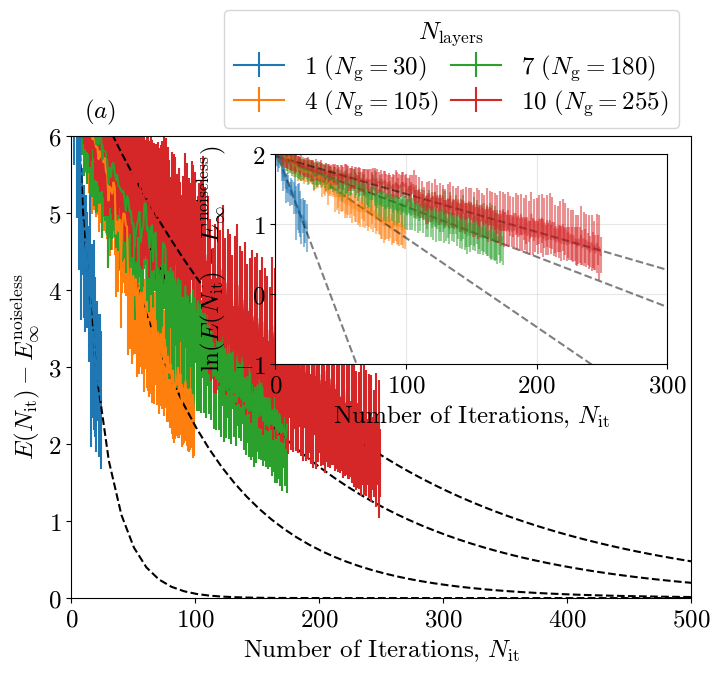

In [19]:
# Create main figure and subplot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)

# Create inset axes for log-linear plot
inset_ax = fig.add_axes([0.38, 0.5, 0.49, 0.35])  # [left, bottom, width, height]

gam = []
gam_err = []
xx = np.arange(0, 25000, 1, dtype=int)
fit_ran = 25

for gt in range(0, len(res_data_idm), 3):
    fit_range = (gt+1)*fit_ran
    yy = np.array(res_data_idm[gt])-val_list_idm[gt]
    xp = xx[0:fit_range]
    yp = yy[0:fit_range]
    std_devs = res_data_ids[gt][0:fit_range]

    # Fit model with weights
    params, cv = curve_fit(exp_model, xp, yp, sigma=std_devs, absolute_sigma=True)
    a, b = params
    a_err, b_err = np.sqrt(np.diag(cv))
    gam_err.append(b_err)
    gam.append(b)

    # Plot in main axes
    ax.errorbar(xp, yp, yerr=std_devs, fmt='-', label=r'$%s ~(N_\text{g} = %d)$' %(gt+1, gate_ctt[gt]))
    
    # Plot fitted exponential model in main axes
    x_fit = np.linspace(0, 1000, 100)
    y_fit = exp_model(x_fit, a, b)
    ax.plot(x_fit, y_fit, '--k')
    
    # Plot in inset (log-linear)
    inset_ax.errorbar(xp, np.log(yp), yerr=std_devs/yp, fmt='-', alpha=0.5)
    inset_ax.plot(x_fit, np.log(y_fit), '--k', alpha=0.5)

# Main axes settings
#ax.set_yscale('log')
ax.set_xlabel(r'$\text{Number of Iterations,}~N_\text{it}$', fontsize=18)
ax.set_ylabel(r'$ E(N_\text{it}) - E_{\infty}^\text{noiseless}$', fontsize=18)
ax.set_xlim(0, 500)
ax.set_ylim(0, 6)
ax.legend(bbox_to_anchor=(1, 1.3), ncol=2, title=r'$N_\text{layers}$', fontsize=18, labelspacing=0.2, columnspacing=0.5)

# Inset axes settings
inset_ax.set_xlim(0, 300)
inset_ax.set_ylim(-1, 2)
inset_ax.set_xlabel(r'$\text{Number of Iterations,}~N_\text{it}$', fontsize=18)
inset_ax.set_ylabel(r'$\ln(E(N_\text{it}) - E_{\infty}^\text{noiseless})$', fontsize=18)
inset_ax.tick_params(axis='both', which='major', labelsize=18)
inset_ax.grid(True, alpha=0.3)

# Add (a)
ax.text(0.02, 1.02, r"$(a)$", fontsize=18, transform=ax.transAxes, verticalalignment='bottom')

from matplotlib.ticker import FuncFormatter
_fmt = FuncFormatter(lambda x, _: f'${x:g}$')
ax.xaxis.set_major_formatter(_fmt)
ax.yaxis.set_major_formatter(_fmt)
inset_ax.xaxis.set_major_formatter(_fmt)
inset_ax.yaxis.set_major_formatter(_fmt)

plt.savefig('../../figures/noiseless_E_t_inset_rya.png', bbox_inches='tight')
plt.show()

#### for all depths for complete analysis

/tmp/ipykernel_14024/2599236198.py:3: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)


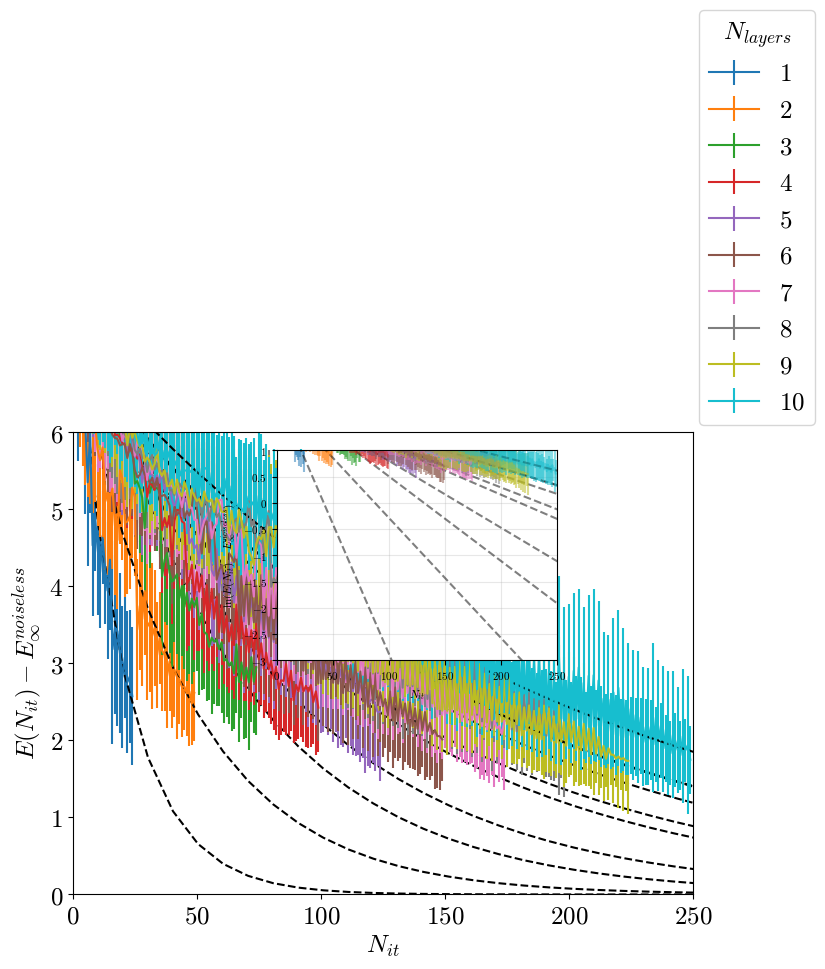

In [20]:
# Create main figure and subplot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)

# Create inset axes for log-linear plot
inset_ax = fig.add_axes([0.38, 0.5, 0.35, 0.35])  # [left, bottom, width, height]

gam = []
gam_err = []
xx = np.arange(0, 25000, 1, dtype=int)
fit_ran = 25

for gt in range(0, len(res_data_idm), 1):
    fit_range = (gt+1)*fit_ran
    yy = np.array(res_data_idm[gt])-val_list_idm[gt]
    xp = xx[0:fit_range]
    yp = yy[0:fit_range]
    std_devs = res_data_ids[gt][0:fit_range]

    # Fit model with weights
    params, cv = curve_fit(exp_model, xp, yp, sigma=std_devs, absolute_sigma=True)
    a, b = params
    a_err, b_err = np.sqrt(np.diag(cv))
    gam_err.append(b_err)
    gam.append(b)

    # Plot in main axes
    ax.errorbar(xp, yp, yerr=std_devs, fmt='-', label=r'$%s$' %(gt+1))
    
    # Plot fitted exponential model in main axes
    x_fit = np.linspace(0, 1000, 100)
    y_fit = exp_model(x_fit, a, b)
    ax.plot(x_fit, y_fit, '--k')
    
    # Plot in inset (log-linear)
    inset_ax.errorbar(xp, np.log(yp), yerr=std_devs/yp, fmt='-', alpha=0.5)
    inset_ax.plot(x_fit, np.log(y_fit), '--k', alpha=0.5)

# Main axes settings
#ax.set_yscale('log')
ax.set_xlabel(r'$N_{it}$')
ax.set_ylabel(r'$ E(N_{it}) - E_{\infty}^{noiseless}$')
ax.set_xlim(0, 250)
ax.set_ylim(0, 6)
ax.legend(bbox_to_anchor=(0.99, 0.99), title=r'$N_{layers}$')

# Inset axes settings
inset_ax.set_xlim(0, 250)
inset_ax.set_ylim(-3, 1)
inset_ax.set_xlabel(r'$N_{it}$', fontsize=8)
inset_ax.set_ylabel(r'$\ln(E(N_{it}) - E_{\infty}^{noiseless})$', fontsize=8)
inset_ax.tick_params(axis='both', which='major', labelsize=8)
inset_ax.grid(True, alpha=0.3)
#plt.savefig('figs/noiseless_E_t_inset.pdf', bbox_inches='tight')

from matplotlib.ticker import FuncFormatter
_fmt = FuncFormatter(lambda x, _: f'${x:g}$')
ax.xaxis.set_major_formatter(_fmt)
ax.yaxis.set_major_formatter(_fmt)
inset_ax.xaxis.set_major_formatter(_fmt)
inset_ax.yaxis.set_major_formatter(_fmt)

plt.show()

### fitting convergence rate

In [21]:
n_lay = 10

In [22]:
x_off = 20

In [23]:
# Define power law
def noiseless_power_model(x, a, b):
    return a * ((x-x_off)**-b)

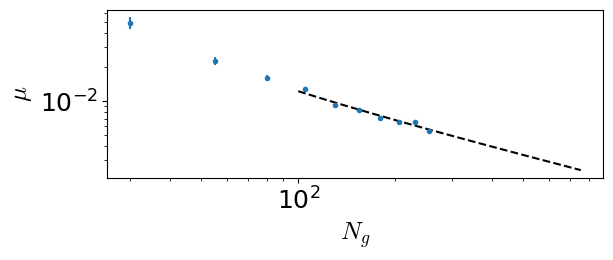

In [24]:
#fitting power law on noiseless gamma
fig = plt.figure()
ax = fig.add_subplot(2, 1, 1)
plt.errorbar(gate_ctt[0:n_lay], gam[0:n_lay], yerr=gam_err[0:n_lay], fmt='.')
#pfit, cv  = np.polyfit(gate_ct[0:n_lay], np.log(gam[0:n_lay]), w = 1/np.sqrt(gam_err[0:n_lay]), deg=1, cov = True)

#Fit model with weights
pm, cv = curve_fit(noiseless_power_model, gate_ctt[0:n_lay], gam[0:n_lay], sigma=gam_err[0:n_lay], absolute_sigma=True)
a, b = pm
a_err, b_err = np.sqrt(np.diag(cv))
#Plot fitted model
x_fit = np.linspace(100, gate_ctt[n_lay-1]+500, 1000)
y_fit = noiseless_power_model(x_fit, a, b)
#plt.plot(x_fit, y_fit)

y_fitt = noiseless_power_model(gate_ctt[0:n_lay], a, b)

residuals = np.array(gam[0:n_lay]) - y_fitt
chi_sq = np.sum((residuals / np.array(gam_err[0:n_lay]))**2)
ss_res = np.sum(residuals**2)
ss_tot = np.sum(( np.array(gam[0:n_lay])-np.mean( np.array(gam[0:n_lay])))**2)
r_sq = 1 - (ss_res / ss_tot)

# Create sequence of 100 numbers from 0 to 100 
#xn = np.linspace(1, gate_ct[n_lay-1], num=50)

# Plot regression line
ax.plot(x_fit, y_fit, '--k', lw=1.5);
ax.set_xlabel(r'$N_g$')
ax.set_xticks(gate_ctt)
ax.set_ylabel(r'$ \mu$')
ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_xlim([100,2000])
#ax.set_ylim([0.005,0.5])
#plt.savefig('noiseless_gamma_fit.pdf', bbox_inches = 'tight')
plt.show()

In [25]:
print(a, a_err, b, b_err)

0.29536339910893256 0.03595685824612809 0.725427077872602 0.024150797152171964


In [26]:
print(r_sq, chi_sq)

0.9751136662731047 12.666846892858054


### selected noisy data plot

In [27]:
sel = 2

In [28]:
base_expo[sel]

[1, 5]

In [29]:
res_data_mean = noisy_data_mean['%s'%sel]
res_data_std = noisy_data_std['%s'%sel]
val_list = noisy_data_val_m['%s'%sel]

In [30]:
# Define exponential model
def exp_model(x, a, b):
    return a * np.exp(-b * x)

/tmp/ipykernel_14024/2599236198.py:3: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)


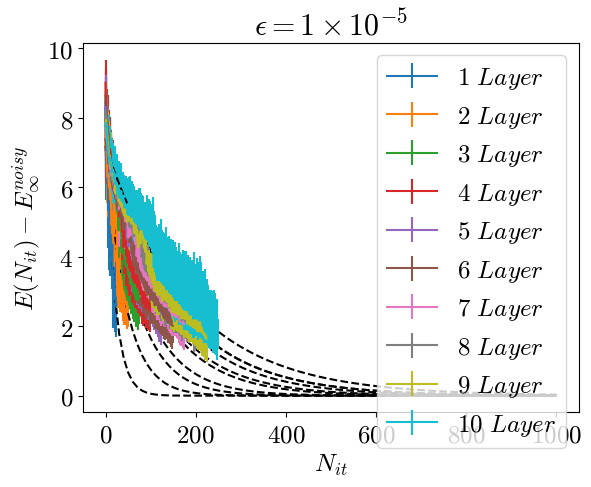

In [31]:
#fitting using the mean data with error propagation
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
alp = []
alp_err = []
E00 = []
E00_err = []
xx = np.arange(0, 25000, 1, dtype = int)
fit_ran = 25
for gt in range(0, len(res_data_mean), 1): 
#for gt in [3]:
    fit_range = (gt+1)*fit_ran
    yy = np.array(res_data_mean[gt])-val_list[gt]
    xp = xx[0:fit_range]
    yp = yy[0:fit_range]
    std_devs = res_data_std[gt][0:fit_range]

    # Fit model with weights
    params, cv = curve_fit(exp_model, xp, yp, sigma=std_devs, absolute_sigma=True)
    a, b = params
    a_err, b_err = np.sqrt(np.diag(cv))
    alp_err.append(b_err)
    alp.append(b)
    E00.append(a)
    E00_err.append(a_err)
    #y_fit = exp_model(xp, a, b)

    plt.errorbar(xp, yp, yerr=std_devs, fmt='-', label = r'$%s~Layer$' %(gt+1))

    # Plot fitted exponential model
    x_fit = np.linspace(0, 1000, 100)
    y_fit = exp_model(x_fit, a, b)
    #plt.plot(x_fit, y_fit, '--k', label= r'$F~%s~Layer$' %(gt+1))
    plt.plot(x_fit, y_fit, '--k')

plt.title(r'$\epsilon = %s \times 10^{-%s}$'%(base_expo[sel][0], base_expo[sel][1]))
#ax.set_yscale('log')
ax.set_xlabel(r'$N_{it}$')
ax.set_ylabel(r'$ E(N_{it}) - E_{\infty}^{noisy}$')
#plt.axis([0, 250, 0, 4])
#ax.legend(ncol = 2, bbox_to_anchor = (1, 0.1))
ax.legend()
#plt.savefig('noisy_alpha.pdf', bbox_inches = 'tight')

from matplotlib.ticker import FuncFormatter
_fmt = FuncFormatter(lambda x, _: f'${x:g}$')
ax.xaxis.set_major_formatter(_fmt)
ax.yaxis.set_major_formatter(_fmt)

plt.show()

In [32]:
E00

[7.963926193685523,
 7.418246196603082,
 8.312309336455582,
 7.973839945056868,
 7.3911327757355805,
 7.093885915433864,
 7.142438063054825,
 7.181572736879308,
 7.201697199225938,
 7.185678695813339]

In [33]:
E00_err

[0.46184891314287324,
 0.3154767852550529,
 0.23540526971122097,
 0.2316196824750311,
 0.202035395289147,
 0.1808322364308468,
 0.1757996026980984,
 0.14637059242649203,
 0.14073785131969824,
 0.13075895300054327]

In [34]:
alp

[0.04943613127270314,
 0.02284709052820751,
 0.016104112921539706,
 0.01274274283974709,
 0.009215234237595085,
 0.008342997518827246,
 0.007189442530333964,
 0.006531149297118554,
 0.00653290565246736,
 0.00543386238690675]

In [35]:
alp_err

[0.005863115966072835,
 0.0017661654784013213,
 0.0009658413441466958,
 0.0006599024726741399,
 0.0005308064432380065,
 0.0003775082782563892,
 0.00031019621434487073,
 0.00023938784516675408,
 0.00019630381149248402,
 0.00017053310569437456]

### fitting noisy $\alpha$ for all $\epsilon$

In [36]:
n_lay = 10

In [37]:
# Define exponential model
def exp_model(x, a, b):
    return a * np.exp(-b * x)

In [38]:
alp_list = []
alp_err_list = []
xx = np.arange(0, 25000, 1, dtype = int)
fit_ran = 25
for gt in range(len(base_expo)):
    res_data_mean = noisy_data_mean['%s'%gt]
    res_data_std = noisy_data_std['%s'%gt]
    val_list = noisy_data_val_m['%s'%gt]
    #fitting using the mean data with error propagation
    alp = []
    alp_err = []
    for gt in range(0, len(res_data_mean), 1):
        fit_range = (gt+1)*fit_ran
        yy = np.array(res_data_mean[gt])-val_list[gt]
        xp = xx[0:fit_range]
        yp = yy[0:fit_range]
        std_devs = res_data_std[gt][0:fit_range]
        # Fit model with weights
        params, cv = curve_fit(exp_model, xp, yp, sigma=std_devs, absolute_sigma=True)
        a, b = params
        a_err, b_err = np.sqrt(np.diag(cv))
        alp_err.append(b_err)
        alp.append(b)
    alp_list.append(alp)
    alp_err_list.append(alp_err)

/tmp/ipykernel_14024/2599236198.py:3: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)
/home/harshit-verma/Desktop/eviden/eviden/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:538: RuntimeWarning: overflow encountered in multiply
  return transform * (func(xdata, *params) - ydata)
/tmp/ipykernel_14024/2599236198.py:3: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * x)


In [39]:
x_off = 20

In [40]:
# Define fit model
def noisy_power_model(x, a, b):
    #return a * np.exp(-b * x)
    return a * ((x-x_off)**-b)

In [41]:
import itertools
marker = itertools.cycle(('o', 'v', 's', 'd', '*', '^', 'x', 'p')) 

### Plotting $\nu$

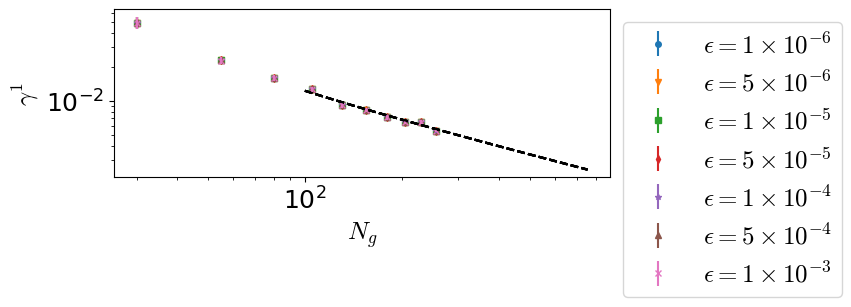

0.9748839409617336


In [42]:
fig = plt.figure()
ax = fig.add_subplot(2, 1, 1)
resi = []
rsq = []
csq = []
alp_err_fit = []
alp_fit = []
bet_err_fit = []
bet_fit = []
for gt in range(len(alp_list)):
    plt.errorbar(gate_ctt[0:n_lay], alp_list[gt][0:n_lay], yerr=alp_err_list[gt][0:n_lay], fmt = next(marker), markersize=4, barsabove = True, label = r'$\epsilon = %s \times 10^{-%s}$'%(base_expo[gt][0], base_expo[gt][1]))
    #pfit, cv  = np.polyfit(gate_ct[0:n_lay], np.log(gam[0:n_lay]), w = 1/np.sqrt(gam_err[0:n_lay]), deg=1, cov = True)
        
    #Fit model with weights
    pm, cv = curve_fit(noisy_power_model, gate_ctt[0:n_lay], alp_list[gt][0:n_lay], sigma=alp_err_list[gt][0:n_lay], absolute_sigma=True)
    a, b = pm
    a_err, b_err = np.sqrt(np.diag(cv))
    #Plot fitted exponential model
    x_fit = np.linspace(100, gate_ctt[n_lay-1]+500, 1000)
    y_fit = noisy_power_model(x_fit, a, b)
    #plt.plot(x_fit, y_fit)
    
    #for evaluating residuals
    y_fitt = noisy_power_model(gate_ctt[0:n_lay], a, b)
    
    residuals = np.array(alp_list[gt][0:n_lay]) - y_fitt
    chi_sq = np.sum((residuals / np.array(alp_err_list[gt][0:n_lay]))**2)
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum(( np.array(alp_list[gt][0:n_lay])-np.mean(np.array(alp_list[gt][0:n_lay])))**2)
    r_sq = 1 - (ss_res / ss_tot)

    resi.append(residuals)
    rsq.append(r_sq)
    csq.append(chi_sq)

    alp_err_fit.append(a_err)
    bet_err_fit.append(b_err)
    alp_fit.append(a)
    bet_fit.append(b)
    
    # Create sequence of 100 numbers from 0 to 100 
    #xn = np.linspace(1, gate_ct[n_lay-1], num=50)
    
    # Plot regression line
    ax.plot(x_fit, y_fit, '--k', lw=1.5);
ax.set_xlabel(r'$N_g$')
ax.set_xticks(gate_ctt)
    
#plt.savefig('noiseless_gamma_fit.pdf', bbox_inches = 'tight')
plt.legend(bbox_to_anchor = (1, 1))
ax.set_ylabel(r'$ \gamma^1$')
ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_xlim([50,1000])
#ax.set_ylim([0.005,0.5])
#plt.savefig('noisy_alpha_fit.pdf', bbox_inches = 'tight')
plt.show()
print(np.mean(rsq))

In [43]:
alp_fit

[0.2951706525701785,
 0.29622766426260255,
 0.2955071027822108,
 0.2974705505946476,
 0.2980570377772851,
 0.2977988192879353,
 0.2936868113931853]

In [44]:
alp_err_fit

[0.0359376332719324,
 0.03607488196361,
 0.035958571705292465,
 0.036247080984813655,
 0.03621878972167443,
 0.0362596915630129,
 0.03577302371280033]

In [45]:
bet_fit

[0.7250971804490035,
 0.7258066863247788,
 0.7253653540445131,
 0.7270943022421295,
 0.7272897883018311,
 0.72707873576263,
 0.7241013287402174]

In [46]:
bet_err_fit

[0.024152818340273583,
 0.024149785765024672,
 0.024146801950036326,
 0.024190935563105507,
 0.02411792600445594,
 0.02416733733432127,
 0.024153662362755055]

In [47]:
rsq

[0.9750522669006751,
 0.9758545064199717,
 0.9748669510605799,
 0.9737498853623969,
 0.9731044525690214,
 0.9748817252203407,
 0.9766777991991497]

In [48]:
csq

[12.549444122466424,
 12.150610094845812,
 12.527563143313802,
 12.154179640097894,
 12.448647885133548,
 12.098275664021836,
 12.417388821683673]

In [49]:
np.mean(alp_fit)

0.2962740912382921

In [50]:
np.mean(alp_err_fit)

0.03606709613187659

In [51]:
np.mean(bet_fit)

0.7259761965521576

In [52]:
np.mean(bet_err_fit)

0.02415418104571034

In [53]:
strt = 0

### Plotting $\nu$ and $\mu$

/tmp/ipykernel_14024/3994161775.py:3: RuntimeWarning: invalid value encountered in power
  return a * ((x-x_off)**-b)
/tmp/ipykernel_14024/1784819297.py:4: RuntimeWarning: invalid value encountered in power
  return a * ((x-x_off)**-b)
/tmp/ipykernel_14024/2875362783.py:106: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim([0, 500])


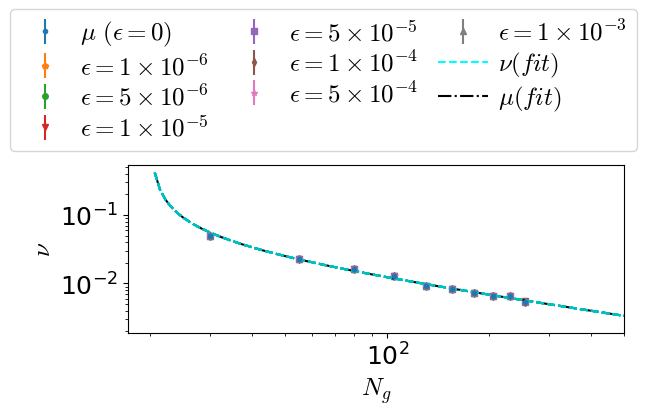

In [54]:
import matplotlib.lines as mlines

fig = plt.figure()
ax = fig.add_subplot(2, 1, 1)
resi = []
rsq = []
csq = []
alp_err_fit = []
alp_fit = []
bet_err_fit = []
bet_fit = []

#plt.figure(figsize=(8, 4))
#firs noiseless gamma
plt.errorbar(gate_ctt[strt:n_lay], gam[strt:n_lay], yerr=gam_err[strt:n_lay], fmt='.',  label = r'$\mu~(\epsilon = 0)$')
#pfit, cv  = np.polyfit(gate_ct[0:n_lay], np.log(gam[0:n_lay]), w = 1/np.sqrt(gam_err[0:n_lay]), deg=1, cov = True)

#Fit model with weights
pm, cv = curve_fit(noiseless_power_model, gate_ctt[strt:n_lay], gam[strt:n_lay], sigma=gam_err[strt:n_lay], absolute_sigma=True)
aa, bb = pm
aa_err, bb_err = np.sqrt(np.diag(cv))
#Plot fitted exponential model
x_fit = np.linspace(1, gate_ctt[n_lay-1]+500, 1000)
y_fit = noiseless_power_model(x_fit, aa, bb)
#plt.plot(x_fit, y_fit)

#for residual from exact points at fit points
y_fitt = noiseless_power_model(gate_ctt[strt:n_lay], aa, bb)

# Plot regression line
ax.plot(x_fit, y_fit, '-.k', lw=1.5);

resi_0 = np.array(gam[strt:n_lay]) - y_fitt
chi_sq_0 = np.sum((resi_0 / np.array(gam_err[strt:n_lay]))**2)
ss_res_0 = np.sum(resi_0**2)
ss_tot_0 = np.sum(( np.array(gam[strt:n_lay])-np.mean( np.array(gam[strt:n_lay])))**2)
r_sq_0 = 1 - (ss_res_0 / ss_tot_0)

# Create sequence of 100 numbers from 0 to 100 
#xn = np.linspace(1, gate_ct[n_lay-1], num=50)

#now noisy alpha

for gt in range(len(alp_list)):
    plt.errorbar(gate_ctt[strt:n_lay], alp_list[gt][strt:n_lay], yerr=alp_err_list[gt][strt:n_lay], fmt = next(marker), markersize=4, barsabove = True, label = r'$\epsilon = %s \times 10^{-%s}$'%(base_expo[gt][0], base_expo[gt][1]))
    #pfit, cv  = np.polyfit(gate_ct[0:n_lay], np.log(gam[0:n_lay]), w = 1/np.sqrt(gam_err[0:n_lay]), deg=1, cov = True)
        
    #Fit model with weights
    pm, cv = curve_fit(noisy_power_model, gate_ctt[strt:n_lay], alp_list[gt][strt:n_lay], sigma=alp_err_list[gt][strt:n_lay], absolute_sigma=True)
    a, b = pm
    a_err, b_err = np.sqrt(np.diag(cv))
    #Plot fitted exponential model
    x_fit = np.linspace(1, gate_ctt[n_lay-1]+500, 1000)
    y_fit = noisy_power_model(x_fit, a, b)
    #plt.plot(x_fit, y_fit)
    
    y_fitt = noisy_power_model(gate_ctt[strt:n_lay], a, b)
    
    residuals = np.array(alp_list[gt][strt:n_lay]) - y_fitt
    chi_sq = np.sum((residuals / np.array(alp_err_list[gt][strt:n_lay]))**2)
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((np.array(alp_list[gt][strt:n_lay])-np.mean(np.array(alp_list[gt][strt:n_lay])))**2)
    r_sq = 1 - (ss_res / ss_tot)

    resi.append(residuals)
    rsq.append(r_sq)
    csq.append(chi_sq)

    alp_err_fit.append(a_err)
    bet_err_fit.append(b_err)
    alp_fit.append(a)
    bet_fit.append(b)
    
    # Create sequence of 100 numbers from 0 to 100 
    #xn = np.linspace(1, gate_ct[n_lay-1], num=50)
    
    # Plot regression line
    ax.plot(x_fit, y_fit, '--c', lw=1.5)

# Add an extra line in the legend
l4 = mlines.Line2D([], [], color="cyan", linestyle="--", label = r"$\nu(fit)$")
l5 = mlines.Line2D([], [], color="k", linestyle="-.", label = r"$\mu(fit)$")

# Get existing handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Add the extra line to the handles
handles.append(l4)
handles.append(l5)

# Create the legend with all lines
plt.legend(handles=handles, ncol = 3,     
           labelspacing=0.2,
            columnspacing=0.8,    # vertical space between entries (default ~0.5)
            bbox_to_anchor = (1.05, 2),
            handletextpad=0.4)   # space between handle and text

ax.set_xlabel(r'$N_g$')
ax.set_xticks(gate_ctt)
    
#plt.savefig('noiseless_gamma_fit.pdf', bbox_inches = 'tight')
#plt.legend(bbox_to_anchor = (0.1, 1.1), ncol =3)
ax.set_ylabel(r'$ \nu$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim([0, 500])
#ax.set_ylim([0.005, 0.5])
#plt.savefig('../../figures/noisy_alpha_fit_COBY_rya.pdf', bbox_inches = 'tight')
plt.show()

#### Modified power law shown on log-log plot

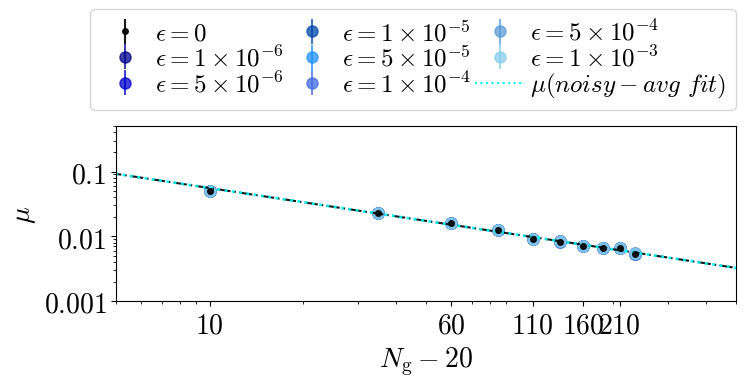

In [55]:
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(2, 1, 1)
resi = []
rsq = []
csq = []
alp_err_fit = []
alp_fit = []
bet_err_fit = []
bet_fit = []

# ensure start index and n_lay are set
# strt = 0
# n_lay = 10

# Define shades of blue for noisy data (darker shades for better visibility)
blue_shades = ['#00008B', '#0000CD', '#0047AB', '#1E90FF', '#4169E1', '#5B9BD5', '#87CEEB']

# Define line styles for better distinction
line_styles = ['-', '--', '-.', ':', (0, (5, 2, 1, 2)), (0, (3, 1, 1, 1)), (0, (5, 5))]

# Plot noiseless gamma vs (Ng-offset)
x_data = gate_ctt[strt:n_lay]
x_shift = x_data - x_off

ax.errorbar(x_shift, gam[strt:n_lay], yerr=gam_err[strt:n_lay], fmt='.', color='black', alpha=0.9, markersize=8,label=r'$\epsilon = 0$')

# Fit noiseless using original offsetted noiseless power model
pm, cv = curve_fit(noiseless_power_model, gate_ctt[strt:n_lay], gam[strt:n_lay], sigma=gam_err[strt:n_lay], absolute_sigma=True)
aa, bb = pm
aa_err, bb_err = np.sqrt(np.diag(cv))

# prepare x for plotting fit (avoid x==offset to prevent singularity)
x_fit = np.linspace(x_off+1, gate_ctt[n_lay-1] + 500, 1000)
y_fit = aa * ((x_fit - x_off) ** -bb)
ax.plot(x_fit - x_off, y_fit, '-.k', lw=1.5, alpha=0.9) #fit line for noiseless gamma

# noiseless fit stats
y_fitt = aa * ((gate_ctt[strt:n_lay] - x_off) ** -bb)
resi_0 = np.array(gam[strt:n_lay]) - y_fitt
chi_sq_0 = np.sum((resi_0 / np.array(gam_err[strt:n_lay])) ** 2)
ss_res_0 = np.sum(resi_0 ** 2)
ss_tot_0 = np.sum((np.array(gam[strt:n_lay]) - np.mean(np.array(gam[strt:n_lay]))) ** 2)
r_sq_0 = 1 - (ss_res_0 / ss_tot_0)

# Plot noisy data and fits on shifted x axis
for gt in range(len(alp_list)):
    # mask non-positive values to avoid issues on log scale
    x_all = gate_ctt[strt:n_lay]
    x_sh = x_all - x_off
    y_all = np.array(alp_list[gt][strt:n_lay])
    y_err = np.array(alp_err_list[gt][strt:n_lay])
    pos_mask = y_all > 0

    ax.errorbar(x_sh[pos_mask], y_all[pos_mask], yerr=y_err[pos_mask],
                 fmt='o', markersize=8, color=blue_shades[gt % len(blue_shades)], 
                 alpha=0.75, barsabove=True,
                 label=r'$\epsilon = %s \times 10^{-%s}$' % (base_expo[gt][0], base_expo[gt][1]))

    pm, cv = curve_fit(noisy_power_model, gate_ctt[strt:n_lay][pos_mask], y_all[pos_mask],
                       sigma=y_err[pos_mask], absolute_sigma=True)
    a, b = pm
    a_err, b_err = np.sqrt(np.diag(cv))

    #x_fit_n = np.linspace(x_off + 1, gate_ctt[n_lay-1] + 500, 1000)
    #y_fit_n = a * ((x_fit_n - x_off) ** -b)
    #ax.plot(x_fit_n - x_off, y_fit_n, linestyle=line_styles[gt % len(line_styles)], 
    #        color=blue_shades[gt % len(blue_shades)], lw=1, alpha=0.8)

    y_fitt_n = a * ((gate_ctt[strt:n_lay] - x_off) ** -b)
    residuals = y_all - y_fitt_n
    chi_sq = np.sum((residuals[pos_mask] / y_err[pos_mask]) ** 2)
    ss_res = np.sum(residuals[pos_mask] ** 2)
    ss_tot = np.sum((y_all[pos_mask] - np.mean(y_all[pos_mask])) ** 2)
    r_sq = 1 - (ss_res / ss_tot)

    resi.append(residuals)
    rsq.append(r_sq)
    csq.append(chi_sq)
    alp_err_fit.append(a_err)
    bet_err_fit.append(b_err)
    alp_fit.append(a)
    bet_fit.append(b)

# Plot average noisy fit line (without label for manual legend control)
a_avg = np.mean(alp_fit)
b_avg = np.mean(bet_fit)
x_fit_avg = np.linspace(x_off+1, gate_ctt[n_lay-1] + 500, 1000)
y_fit_avg = a_avg * ((x_fit_avg - x_off) ** -b_avg)
ax.plot(x_fit_avg - x_off, y_fit_avg, ':', color='cyan', lw=2, alpha=0.9)

# legend and axis formatting (shifted ticks)
#l5 = mlines.Line2D([], [], color="m", linestyle="-.", label=r"$\mu(noiseless-fit)$")
l4 = mlines.Line2D([], [], color="cyan", linestyle=":", label=r"$\mu(noisy-avg~fit)$")
handles, labels = ax.get_legend_handles_labels()
#handles.append(l5)
handles.append(l4)
ax.legend(handles=handles, ncol=3, labelspacing=0, columnspacing=0.15,
           bbox_to_anchor=(1.02, 1.74), handletextpad=0.2)

ax.set_xlabel(r'$N_\text{g}-%d$' % x_off, fontsize=20)
ax.set_ylabel(r'$\mu$', fontsize=20)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim([5, 500])
ax.set_ylim([0.001, 0.5])

# Show every other data-point tick to avoid crowding on log scale
tick_vals = (gate_ctt - x_off)[::2]
ax.set_xticks(tick_vals)
from matplotlib.ticker import FuncFormatter, NullFormatter
ax.xaxis.set_minor_formatter(NullFormatter())
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: rf'${int(round(x))}$'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: rf'${y:g}$'))
ax.tick_params(axis='both', labelsize=20)
plt.savefig('../../figures/noisy_alpha_fit_shifted_COBY_rya.png', bbox_inches='tight')
plt.show()

### Deviation of mean for noisy fit params from noiseless

In [56]:
aa

0.29536339910893256

In [57]:
np.mean(alp_fit)

0.2962740912382921

In [58]:
alp_err_fit

[0.0359376332719324,
 0.03607488196361,
 0.035958571705292465,
 0.036247080984813655,
 0.03621878972167443,
 0.0362596915630129,
 0.03577302371280033]

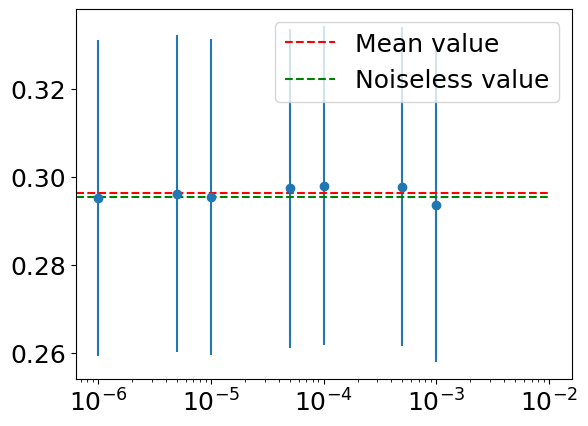

In [59]:
plt.errorbar(eps, alp_fit, yerr=alp_err_fit, fmt='o')
plt.hlines(np.mean(alp_fit), xmin=0, xmax=0.01, colors='r', linestyles='--', label='Mean value')
plt.hlines(aa , xmin=0, xmax=0.01, colors='g', linestyles='--', label='Noiseless value')
plt.xscale('log')
plt.legend()

In [60]:
np.mean(bet_fit)

0.7259761965521576

In [61]:
bb

0.725427077872602

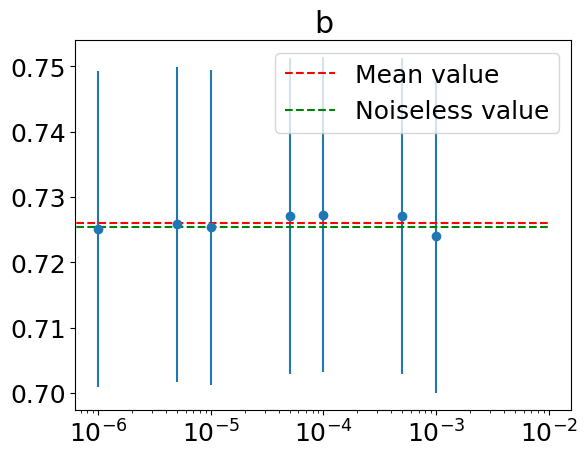

In [62]:
plt.errorbar(eps, bet_fit, yerr=bet_err_fit, fmt='o')
plt.hlines(np.mean(bet_fit), xmin=0, xmax=0.01, colors='r', linestyles='--', label='Mean value')
plt.hlines(bb , xmin=0, xmax=0.01, colors='g', linestyles='--', label='Noiseless value')
plt.xscale('log')
plt.title("b")
plt.legend()

### difference in E(t) noisy and noiseless

In [63]:
xx = np.arange(1, 25001, 1, dtype =int)

In [64]:
sel = 5

0.00922439252163053
0.01284818132853561
-0.0003828392312587854
0.005105667397555411
-0.0038131386700035914
0.00147276814973871
0.004153724300146343
0.007724317259370605
0.0007683056891872661
0.002407774839362572


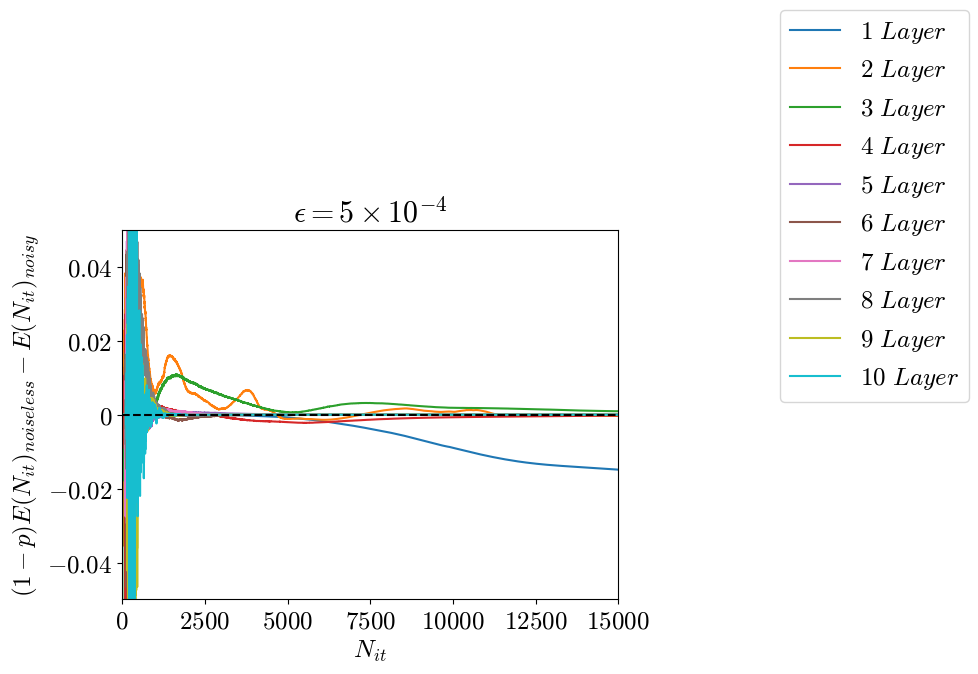

In [65]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
for gt in dep:
    diff = np.multiply(exp_off[sel][gt-1], np.array(res_data_idm[gt-1]))- np.array(noisy_data_mean['%s'%sel][gt-1])
    #print(np.multiply(exp_off[sel][gt-1], res_data_idm[gt-1][-1]) - np.min(res_data_mean[gt-1]))
    #diff = np.multiply(exp_off[sel][gt-1]*np.ones(len(res_data_idm[gt-1])), np.array(res_data_idm[gt-1]))- np.array(res_data_mean[gt-1])
    print(np.mean(diff[0:1000]))
    ax.plot(xx, diff, label = r'$%s~Layer$' %(gt))
ax.set_xlabel(r'$N_{it}$')
ax.set_ylabel(r'$ (1-p)E(N_{it})_{noiseless}- E(N_{it})_{noisy}$')
ax.legend(ncol = 1, bbox_to_anchor = (1.3, 0.5))
plt.axis([0, 15000, -0.05, 0.05])
#ax.set_yscale('log')
plt.title( r'$\epsilon = %s \times 10^{-%s}$'%(base_expo[sel][0], base_expo[sel][1]))
plt.axhline(0, color = 'k', xmin = 0, xmax = 25000, linestyle = '--')
#plt.savefig('opt_trace_diff.pdf', bbox_inches = 'tight')

from matplotlib.ticker import FuncFormatter
_fmt = FuncFormatter(lambda x, _: f'${x:g}$')
ax.xaxis.set_major_formatter(_fmt)
ax.yaxis.set_major_formatter(_fmt)

plt.show()

### difference in $E_\infty$ noisy and noiseless

/tmp/ipykernel_14024/1863687775.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axx.set_xticklabels([f'${x}$' for x in gate_ctt])


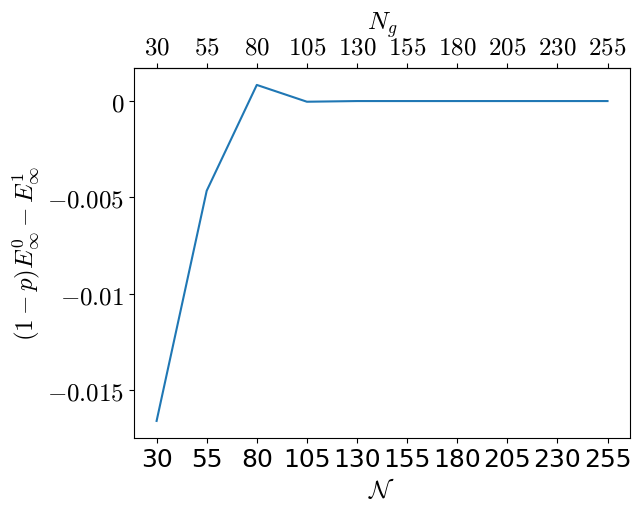

In [66]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
diff = np.multiply(np.array(exp_off[sel]), np.array(val_list_idm)) - np.array(noisy_data_val_m['%s'%sel])
ax.plot(gate_ctt, diff)
from matplotlib.ticker import FuncFormatter
_fmt = FuncFormatter(lambda x, _: f'${x:g}$')
ax.yaxis.set_major_formatter(_fmt)
ax.set_xlabel('$\mathcal{N}$')
ax.set_ylabel(r'$ (1-p)E_{\infty}^0 - E_{\infty}^1$')
ax.set_xticks(gate_ctt)
axx = ax.secondary_xaxis('top')
axx.set_xticklabels([f'${x}$' for x in gate_ctt])
axx.set_xlabel(r'$N_g$')
axx.set_xticks(gate_ctt)
axx.set_xticklabels([f'${x}$' for x in gate_ctt])
#ax.legend(ncol = 2, bbox_to_anchor = (1.5, 0.25))
#plt.axis([0, 5000, -0.5, 0.5])
#ax.set_yscale('log')
plt.show()

### $E_\infty$ as a function of $\mathcal{N}$

In [67]:
import itertools
marker = itertools.cycle(('o-', 'v-', 's-', 'd-', '*-', '^-', 'x-', 'p-')) 

/tmp/ipykernel_14024/1491639556.py:14: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(gate_ctt, val_list_idm, yerr = val_list_ids, fmt='o-', markersize=4,
/tmp/ipykernel_14024/1491639556.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axx.set_xticklabels([f'${x}$' for x in gate_ctt])


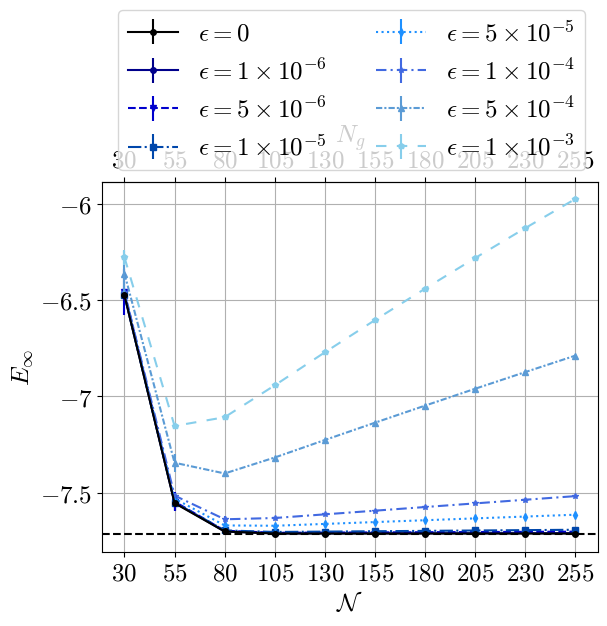

In [68]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

# Define shades of blue for epsilon > 0 (darker shades for better visibility)
blue_shades = ['#00008B', '#0000CD', '#0047AB', '#1E90FF', '#4169E1', '#5B9BD5', '#87CEEB']

# Define line styles for epsilon > 0
line_styles = ['-', '--', '-.', ':', (0, (5, 2, 1, 2)), (0, (3, 1, 1, 1)), (0, (5, 5))]

# Define marker styles
markers = ['o', 'v', 's', 'd', '*', '^', 'p']

# Plot epsilon = 0 in black
plt.errorbar(gate_ctt, val_list_idm, yerr = val_list_ids, fmt='o-', markersize=4, 
             color='black', linestyle='-', label = r'$\epsilon = 0$')

# Plot epsilon > 0 in shades of blue with different line styles
for rt in range(len(base_expo)):
    plt.errorbar(gate_ctt, np.array(noisy_data_val_m['%s'%rt]), yerr = noisy_data_val_s['%s'%rt], 
                 fmt=markers[rt % len(markers)], markersize=4, barsabove = True, 
                 color=blue_shades[rt % len(blue_shades)], 
                 linestyle=line_styles[rt % len(line_styles)],
                 label = r'$\epsilon = %s \times 10^{-%s}$'%(base_expo[rt][0], base_expo[rt][1]))
ax.set_xlabel(r'$\mathcal{N}$')
ax.set_ylabel(r'$ E_\infty$')
ax.set_xticks(gate_ctt)
ax.set_xticklabels([f'${x}$' for x in gate_ctt])
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:g}$'))
axx = ax.secondary_xaxis('top')
axx.set_xticklabels([f'${x}$' for x in gate_ctt])
axx.set_xlabel(r'$N_g$')
axx.set_xticks(gate_ctt)
axx.set_xticklabels([f'${x}$' for x in gate_ctt])
plt.axhline(g_en5, color = 'k', xmin = 0, xmax = 500, linestyle = '--')
plt.legend(ncol = 2, bbox_to_anchor = (1, 1.5))
#ax.set_yscale('log')
plt.grid()
#plt.savefig('noisy_noiseless_conv_COBY.pdf', bbox_inches = 'tight')
plt.show()

/tmp/ipykernel_14024/2716793004.py:14: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "+-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(gate_ctt, val_list_idm, yerr = val_list_ids, fmt='+-', markersize=4,
/tmp/ipykernel_14024/2716793004.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'${x:g}$' for x in ax.get_yticks()], fontdict={'fontsize': 20})


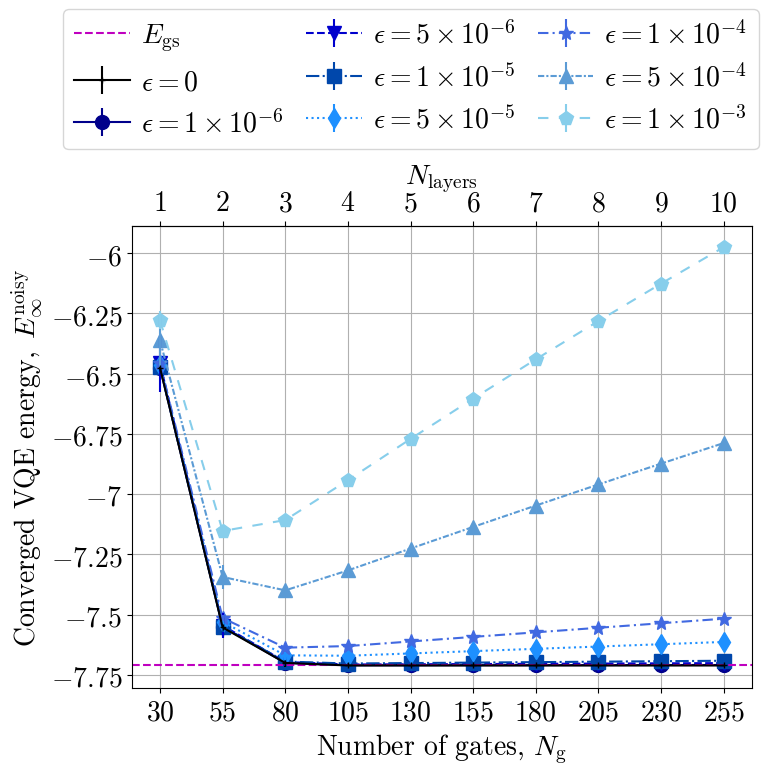

In [69]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)

# Define shades of blue for epsilon > 0 (darker shades for better visibility)
blue_shades = ['#00008B', '#0000CD', '#0047AB', '#1E90FF', '#4169E1', '#5B9BD5', '#87CEEB']

# Define line styles for epsilon > 0
line_styles = ['-', '--', '-.', ':', (0, (5, 2, 1, 2)), (0, (3, 1, 1, 1)), (0, (5, 5))]

# Define marker styles
markers = ['o', 'v', 's', 'd', '*', '^', 'p']

# Plot epsilon = 0 in black
plt.errorbar(gate_ctt, val_list_idm, yerr = val_list_ids, fmt='+-', markersize=4, 
             color='black', linestyle='-', label = r'$\epsilon = 0$')

# Plot epsilon > 0 in shades of blue with different line styles
for rt in range(len(base_expo)):
    plt.errorbar(gate_ctt, np.array(noisy_data_val_m['%s'%rt]), yerr = noisy_data_val_s['%s'%rt], 
                 fmt=markers[rt % len(markers)], markersize=10, barsabove = True, 
                 color=blue_shades[rt % len(blue_shades)], 
                 linestyle=line_styles[rt % len(line_styles)],
                 label = r'$\epsilon = %s \times 10^{-%s}$'%(base_expo[rt][0], base_expo[rt][1]))
ax.set_ylabel(r'$ \text{Converged VQE energy},~E_\infty^\text{noisy}$', fontsize=20)
ax.set_xticks(gate_ctt)
ax.set_xlabel(r'$\text{Number of gates, } N_\text{g}$', fontsize=20)
ax.set_xticklabels([f'${x}$' for x in gate_ctt], rotation=0, fontdict={'fontsize': 20})
ax.set_yticklabels([f'${x:g}$' for x in ax.get_yticks()], fontdict={'fontsize': 20})
plt.axhline(g_en5, color = 'm', xmin = 0, xmax = 500, linestyle = '--', label = r'$E_\text{gs}$')
# Create the legend with all lines
plt.legend(ncol = 3,
           loc = "upper center",     
           labelspacing=0.5,
            columnspacing=0.8,    # vertical space between entries (default ~0.5)
            bbox_to_anchor = (0.45, 1.5),
            handletextpad=0.4,
            fontsize = 20)   # space between handle and text
#add secondary x-axis with N_lay = [1, 10]
axx = ax.secondary_xaxis('top')
axx.set_xticks(gate_ctt)
axx.set_xticklabels([f'${x}$' for x in np.arange(1, len(gate_ctt)+1, 1, dtype=int)], fontdict={'fontsize': 20})
axx.set_xlabel(r'$N_\text{layers}$', fontsize=20)
#plt.legend(ncol = 2, loc = "upper center", bbox_to_anchor = (0.5, 1.35))
#ax.set_xscale('log')
plt.grid()
plt.savefig('../../figures/noisy_noiseless_conv_COBY_rya.png', bbox_inches = 'tight')
plt.show()

In [70]:
n_lay = 10

In [71]:
# Define exponential model
def exp_model(x, a, b):
    return a * np.exp(b * x)

In [72]:
# Define exponential model
def lin_model(x, a, b):
    return a * x + b

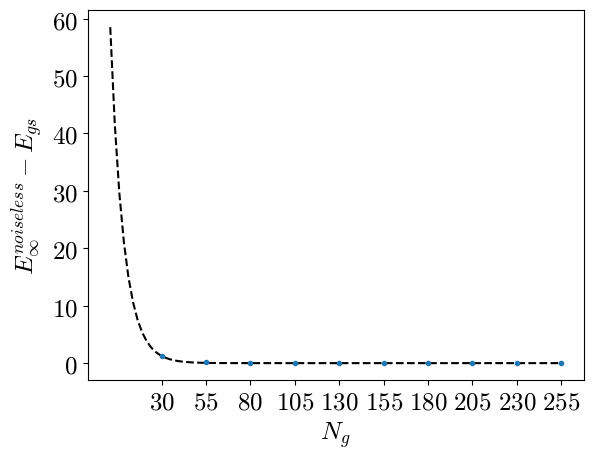

In [73]:
#fitting power law on noiseless gamma
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
#plt.plot(gate_ctt[0:n_lay], np.array(val_list_idm[0:n_lay]) - g_en5, 'o')
plt.errorbar(gate_ctt[0:n_lay], np.array(val_list_idm[0:n_lay]) - g_en5, yerr = val_list_ids[0:n_lay], fmt='.')
#pfit, cv  = np.polyfit(gate_ct[0:n_lay], np.log(gam[0:n_lay]), w = 1/np.sqrt(gam_err[0:n_lay]), deg=1, cov = True)

#Fit model with weights
#pm, cv = curve_fit(lin_model, gate_ctt[0:n_lay], np.log(np.array(val_list_idm[0:n_lay]) - g_en5))
pm, cv = curve_fit(lin_model, gate_ctt[0:n_lay], np.log(np.array(val_list_idm[0:n_lay]) - g_en5), sigma=np.divide(val_list_ids[0:n_lay], np.array(val_list_idm[0:n_lay]) - g_en5), absolute_sigma=True)
a, b = pm
a_er, b_er = np.sqrt(np.diag(cv))

#Plot fitted exponential model
x_fit = np.linspace(1, gate_ctt[n_lay-1], 100)
y_fit = exp_model(x_fit, np.exp(b), a)

a_err = np.exp(b_er)
b_err = a_er

y_fitt = exp_model(gate_ctt[0:n_lay], np.exp(b), a)

residuals = np.array(val_list_idm[0:n_lay]) - g_en5 - y_fitt
chi_sq = np.sum((residuals / np.array(val_list_ids[0:n_lay]))**2)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((np.array(np.array(val_list_idm[0:n_lay]) - g_en5)-np.mean(np.array(val_list_idm[0:n_lay]) - g_en5))**2)
r_sq = 1 - (ss_res / ss_tot)

# Create sequence of 100 numbers from 0 to 100 
#xn = np.linspace(1, gate_ct[n_lay-1], num=50)

# Plot regression line
ax.plot(x_fit, y_fit, '--k', lw=1.5);
ax.set_xlabel(r'$N_g$')
ax.set_xticks(gate_ctt)
ax.set_ylabel(r'$E_{\infty}^{noiseless} - E_{gs}$')

#ax.set_xscale('log')
#ax.set_yscale('log')
#ax.set_xlim([50,900])
#ax.set_ylim([-0.1, 1])
#plt.savefig('COBYLA_plots/noiseless_conv_en_fit_COBY.pdf', bbox_inches = 'tight')

from matplotlib.ticker import FuncFormatter
_fmt = FuncFormatter(lambda x, _: f'${x:g}$')
ax.xaxis.set_major_formatter(_fmt)
ax.yaxis.set_major_formatter(_fmt)

plt.show()

In [74]:
plt.rcParams['text.usetex'] = False

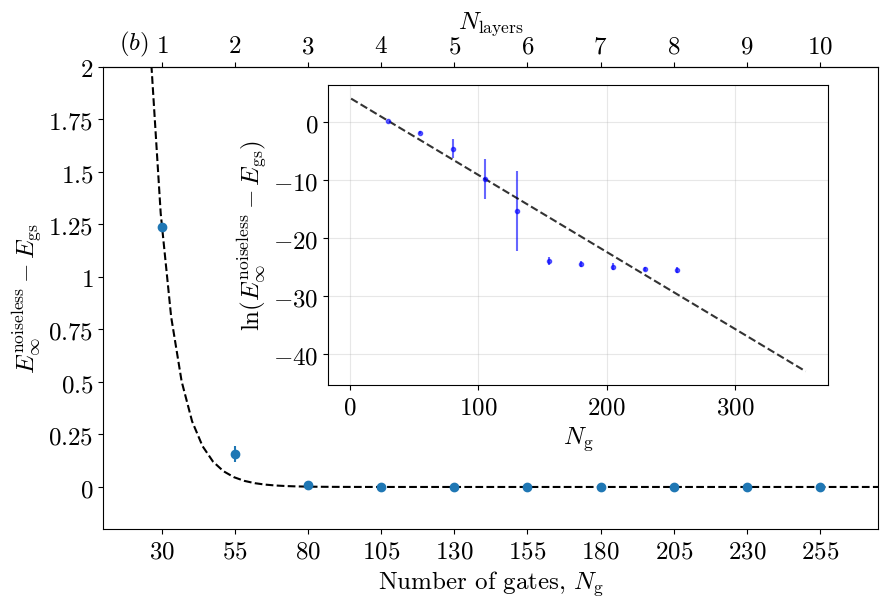

In [75]:
# Create main figure and subplot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)

# Create inset axes for log-linear plot
inset_ax = fig.add_axes([0.35, 0.35, 0.5, 0.5])  # [left, bottom, width, height]

# Main plot
ax.errorbar(gate_ctt[0:n_lay], np.array(val_list_idm[0:n_lay]) - g_en5, 
             yerr=val_list_ids[0:n_lay], fmt='.', markersize=12)

# Fit model with weights
pm, cv = curve_fit(lin_model, gate_ctt[0:n_lay], 
                  np.log(np.array(val_list_idm[0:n_lay]) - g_en5), 
                  sigma=np.divide(val_list_ids[0:n_lay], 
                                np.array(val_list_idm[0:n_lay]) - g_en5), 
                  absolute_sigma=True)
a, b = pm
a_er, b_er = np.sqrt(np.diag(cv))

# Plot fitted exponential model in main axes
x_fit = np.linspace(1, gate_ctt[n_lay-1]+100, 100)
y_fit = exp_model(x_fit, np.exp(b), a)
ax.plot(x_fit, y_fit, '--k', lw=1.5)

# Inset: log-linear plot
y_data = np.array(val_list_idm[0:n_lay]) - g_en5
inset_ax.errorbar(gate_ctt[0:n_lay], np.log(y_data), 
                 yerr=np.divide(val_list_ids[0:n_lay], y_data), 
                 fmt='.', color='blue', alpha=0.6)
inset_ax.plot(x_fit, np.log(y_fit), '--k', lw=1.5, alpha=0.8)

# Main axes settings
ax.set_xlabel(r'$\text{Number of gates, }N_\text{g}$', fontsize=18)
ax.set_xticks(gate_ctt)
ax.set_ylabel(r'$E_{\infty}^\text{noiseless} - E_\text{gs}$', fontsize=18)
ax.set_xlim([10, 275])
ax.set_ylim([-0.2, 2])

#add secondary x-axis with N_lay = [1, 10]
axx = ax.secondary_xaxis('top')
axx.set_xticks(gate_ctt)
axx.set_xticklabels([f'${x}$' for x in np.arange(1, len(gate_ctt)+1, 1, dtype=int)])
axx.set_xlabel(r'$N_\text{layers}$', fontsize=18)

# Inset axes settings
inset_ax.set_xlabel(r'$N_\text{g}$', fontsize=18)
inset_ax.set_ylabel(r'$\ln(E_{\infty}^\text{noiseless} - E_\text{gs})$', fontsize=18)
inset_ax.tick_params(axis='both', which='major', labelsize=18)
inset_ax.grid(True, alpha=0.3)

# Add R² value to inset
r_squared_text = f'$R^2={r_sq:.3f}$'
#inset_ax.text(0.33, 0.90, r_squared_text, transform=inset_ax.transAxes, 
#              fontsize=18, verticalalignment='top')

# Add (b)
ax.text(0.02, 1.02, r"$(b)$", fontsize=18, transform=ax.transAxes, verticalalignment='bottom')

from matplotlib.ticker import FuncFormatter
_fmt = FuncFormatter(lambda x, _: f'${x:g}$')
ax.xaxis.set_major_formatter(_fmt)
ax.yaxis.set_major_formatter(_fmt)
inset_ax.xaxis.set_major_formatter(_fmt)
inset_ax.yaxis.set_major_formatter(_fmt)

plt.savefig('../../figures/noiseless_conv_en_fit_COBY_inset_rya.png', dpi=300, bbox_inches = 'tight')

plt.show()

In [76]:
print(np.exp(b), a_err, a, b_err)

66.83855878194326 1.0352135938266127 -0.13300800045225117 0.0011535925589127376


In [77]:
# exp_model: amplitude * exp(decay * x)
decay       = a           # direct
decay_err   = a_er        # direct

amplitude     = np.exp(b)         # transform intercept
amplitude_err = np.exp(b) * b_er  # error propagation: d(exp(b))/db = exp(b)

In [78]:
decay, decay_err, amplitude, amplitude_err

(-0.13300800045225117,
 0.0011535925589127376,
 66.83855878194326,
 2.3131338887196886)

In [79]:
print(r_sq, chi_sq)

0.990471155449481 7477867.167221077


In [80]:
ss_res

0.012920069599026416

In [81]:
a

-0.13300800045225117

In [82]:
b

4.202280141285618

In [83]:
a_er

0.0011535925589127376

In [84]:
b_er

0.03460777627276715

### Efficiency & Resource Heatmap (from fitted parameters)

In [85]:
import seaborn as sns
from matplotlib import ticker
from multiprocessing import Pool
import itertools as _itertools_hm

# ── Map notebook-fitted variables onto heatmap parameters ──────────────
# aa, bb    : noiseless power-law fit  γ(Ng) = aa*(Ng - x_off)^-bb
# a, b      : lin-model fit  log(E_inf - g_en5) = a*Ng + b
# E00       : list of convergence amplitudes from noisy exp-model fit
# g_en5     : ground-state energy (= δ)
# x_off     : gate-count offset used in power law
# eps       : list of gate error rates; pick the middle entry

_delta   = g_en5                # δ  – asymptotic ground-state energy
_gam1    = aa                   # ν₀ – power-law prefactor
_omg1    = bb                   # δ_exp – power-law exponent
_off     = x_off                # gate-count offset
_E0INF   = np.exp(b)            # β  – E_inf prefactor  (from lin-model)
_kappa   = -a                   # κ  – E_inf decay rate (a < 0)
_E00     = np.mean(E00)         # α  – convergence amplitude
_eps     = 10**(-6)             # gate error rate (middle ε value)

print(f'delta  = {_delta:.6f}')
print(f'gam1   = {_gam1:.6f}  (aa)')
print(f'omg1   = {_omg1:.6f}  (bb)')
print(f'off    = {_off}')
print(f'E0INF  = {_E0INF:.6f}  (exp(b))')
print(f'kappa  = {_kappa:.6f}  (-a)')
print(f'E00    = {_E00:.6f}  (mean of E00 list)')
print(f'eps    = {_eps:.2e}')

delta  = -7.711545
gam1   = 0.295363  (aa)
omg1   = 0.725427  (bb)
off    = 20
E0INF  = 66.838559  (exp(b))
kappa  = 0.133008  (-a)
E00    = 7.486473  (mean of E00 list)
eps    = 1.00e-06


In [86]:
# ── Grid ──────────────────────────────────────────────────────────────
_t = np.linspace(1, 1000, 1000, dtype=int)
_N = np.linspace(1, 2000, 2000, dtype=int)

def _final_energy(NN, tt):
    """Simulated error metric and resource cost using fitted parameters."""
    Einf1 = ((1 - _eps)**NN) * (
        _E0INF * np.exp(-_kappa * NN)
        + _delta
        + _E00 * np.exp(-_gam1 * tt * ((NN - _off)**(-_omg1)))
    ) - _delta
    return [Einf1, NN * tt]

_spann = list(_itertools_hm.product(_N, _t))
with Pool() as _p:
    _res = _p.starmap(_final_energy, _spann)

_met_arr = np.reshape([r[0] for r in _res], (len(_N), len(_t)))
_eng_arr = np.reshape([r[1] for r in _res], (len(_N), len(_t)))
_eff_arr = np.log10(np.divide(1 - _met_arr, _eng_arr))

_contour_vals = [0.01, 0.02, 0.05, 0.10, 0.25, 0.50]
_rows, _cols  = _met_arr.shape
_X, _Y        = np.meshgrid(np.arange(_cols), np.arange(_rows))

plt.rcParams.update({'font.size': 20})

/tmp/ipykernel_14024/247488754.py:10: RuntimeWarning: invalid value encountered in scalar power
  + _E00 * np.exp(-_gam1 * tt * ((NN - _off)**(-_omg1)))
/tmp/ipykernel_14024/247488754.py:10: RuntimeWarning: divide by zero encountered in scalar power
  + _E00 * np.exp(-_gam1 * tt * ((NN - _off)**(-_omg1)))
/tmp/ipykernel_14024/247488754.py:20: RuntimeWarning: invalid value encountered in log10
  _eff_arr = np.log10(np.divide(1 - _met_arr, _eng_arr))


/tmp/ipykernel_14024/3591502608.py:27: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  _paths = _c.collections[0].get_paths()
/tmp/ipykernel_14024/3591502608.py:44: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for _i, _pl in enumerate(_c4.collections):


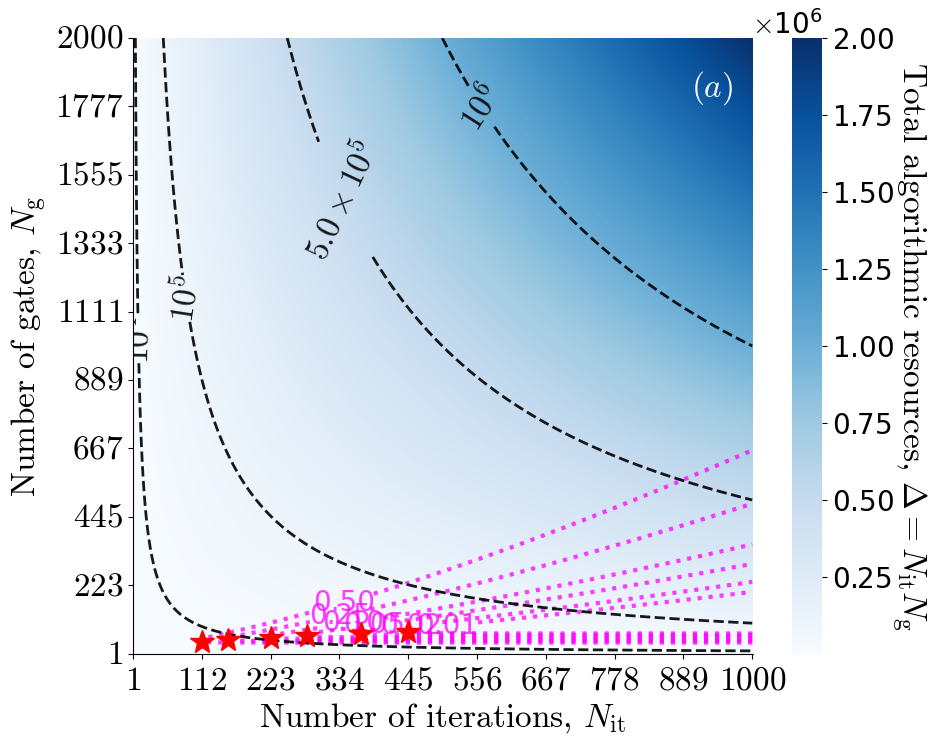

In [87]:
# ── Resources heatmap ─────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 8))

sns.heatmap(
    _eng_arr, cmap='Blues', ax=ax1,
    cbar_kws={
        'label': r'$\text{Total algorithmic resources, } \Delta = N_\text{it} N_\text{g}$',
        'format': ticker.ScalarFormatter(useMathText=True)
    }
)

cbar = ax1.collections[0].colorbar
cbar.ax.set_ylabel(r'$\text{Total algorithmic resources, } \Delta = N_\text{it} N_\text{g}$', rotation=270, labelpad=25, fontsize=24)


ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)

def _sci_tex(x):
    exp = int(np.log10(x))
    base = x / (10**exp)
    return rf'$10^{{{exp}}}$' if abs(base - 1) < 1e-3 else rf'${base:.1f}\times10^{{{exp}}}$'

for _cv in _contour_vals:
    _c = ax1.contour(_X, _Y, _met_arr, levels=[_cv],
                     colors='magenta', alpha=0.75, linestyles='dotted', linewidths=3)
    _paths = _c.collections[0].get_paths()
    if _paths:
        _verts = np.vstack([_p.vertices for _p in _paths])
        _t_v   = np.interp(_verts[:, 0], np.arange(len(_t)), _t)
        _N_v   = np.interp(_verts[:, 1], np.arange(len(_N)), _N)
        _res_v = _N_v * _t_v
        _mi    = np.argmin(_res_v)
        ax1.plot(_verts[_mi, 0], _verts[_mi, 1], 'r*', markersize=18, zorder=10)
        _v = _verts[len(_verts)//2]
        ax1.clabel(_c, inline=True, inline_spacing=0, fontsize=20,
                   fmt={_cv: f'{_cv:.2f}'}, manual=[(_v[0]+20, _v[1]+100)])
        for _txt in ax1.texts: _txt.set_rotation(0)

_resource_levels = [1e4, 1e5, 5e5, 1e6]
_c4 = ax1.contour(_X, _Y, _eng_arr, levels=_resource_levels,
                  colors='black', alpha=0.9, linestyles='dashed', linewidths=2)
_manual_pos = []
for _i, _pl in enumerate(_c4.collections):
    _pp = _pl.get_paths()
    if _pp:
        _v = _pp[len(_pp)//2].vertices
        _mv = _v[len(_v)//2]
        _manual_pos.append((_mv[0], _mv[1] + 500))
ax1.clabel(_c4, fmt=_sci_tex, inline=True, inline_spacing=0,
           fontsize=24, manual=_manual_pos)

ax1.set_xticks(np.linspace(0, _cols-1, 10))
ax1.set_xticklabels([f'${x}$' for x in np.linspace(1, _t[-1], 10, dtype=int)], rotation=0, fontsize=24)
ax1.set_yticks(np.linspace(0, _rows-1, 10))
ax1.set_yticklabels([f'${x}$' for x in np.linspace(_N[0], _N[-1], 10, dtype=int)], fontsize=24)
ax1.invert_yaxis()
ax1.set_xlabel(r'$\text{Number of iterations, } N_\text{it}$', fontsize=24)
ax1.set_ylabel(r'$\text{Number of gates, } N_\text{g}$', fontsize=24)
# Add (a)
ax1.text(900, 1900, r"$(a)$",fontsize=24, verticalalignment='top', color='white', weight='bold')
plt.savefig('../../figures/resource_heatmap_rya.png', bbox_inches='tight', dpi = 300)
plt.show()

/tmp/ipykernel_14024/4275585893.py:23: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  _paths = _c.collections[0].get_paths()


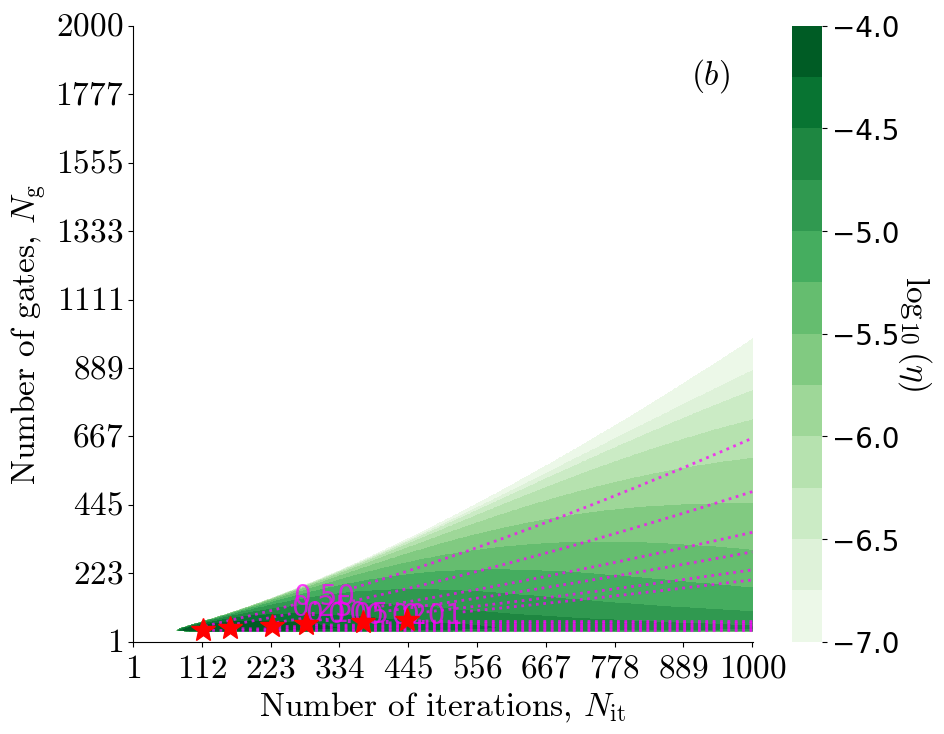

In [88]:
# ── Efficiency heatmap ────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 8))

hm = sns.heatmap(
    _eff_arr,
    cmap=sns.color_palette('Greens', 12),
    ax=ax2,
    cbar_kws={'label': r'$\log_{10}(\eta)$'},
    vmin=-7, vmax=-4,
)


cbar = hm.collections[0].colorbar
cbar.ax.set_ylabel(r'$\log_{10}(\eta)$', rotation=270, labelpad=25, fontsize=24)


ax2.spines['bottom'].set_visible(True)
ax2.spines['left'].set_visible(True)

for _cv in _contour_vals:
    _c = ax2.contour(_X, _Y, _met_arr, levels=[_cv],
                     colors='magenta', alpha=0.75, linestyles='dotted', linewidths=2)
    _paths = _c.collections[0].get_paths()
    if _paths:
        _verts  = np.vstack([_p.vertices for _p in _paths])
        _xi     = np.clip(np.round(_verts[:, 0]).astype(int), 0, len(_t)-1)
        _yi     = np.clip(np.round(_verts[:, 1]).astype(int), 0, len(_N)-1)
        _eff_v  = _eff_arr[_yi, _xi]
        _mai    = np.argmax(_eff_v)
        ax2.plot(_verts[_mai, 0], _verts[_mai, 1], 'r*', markersize=18, zorder=10)
        _v = _verts[len(_verts)//2]
        ax2.clabel(_c, inline=True, inline_spacing=0, fontsize=20,
                   fmt={_cv: f'{_cv:.2f}'}, manual=[(_v[0], _v[1])])
        for _txt in ax2.texts: _txt.set_rotation(0)

ax2.set_xticks(np.linspace(0, _cols-1, 10))
ax2.set_xticklabels([f'${x}$' for x in np.linspace(1, _t[-1], 10, dtype=int)], rotation=0, fontsize=24)
ax2.set_yticks(np.linspace(0, _rows-1, 10))
ax2.set_yticklabels([f'${x}$' for x in np.linspace(_N[0], _N[-1], 10, dtype=int)], fontsize=24)
ax2.invert_yaxis()
ax2.set_xlabel(r'$\text{Number of iterations, } N_\text{it}$', fontsize=24)
ax2.set_ylabel(r'$\text{Number of gates, } N_\text{g}$', fontsize=24)
# Add (a)
ax2.text(900, 1900, r"$(b)$",fontsize=24, verticalalignment='top', color='black', weight='bold')
plt.savefig('../../figures/efficiency_heatmap_rya.png', bbox_inches='tight', dpi = 300)
plt.show()

In [89]:
from IPython.display import display, Markdown

# β error via propagation: d(exp(b)) = exp(b) * db
_beta_err = np.exp(b) * b_er
print(f"β = {_E0INF:.2f} ± {_beta_err:.2f}")
table = (
    "| Parameter | Value (arb. units) |\n"
    "|:---------:|:-----------------:|\n"
    f"| Number of random seeds | {nseeds} |\n"
    f"| Fitting range of $N_{{\\textrm{{it}}}}$ for E($N_{{\\textrm{{it}}}}$) | ${fit_ran} N_{{\\textrm{{layers}}}}$ |\n"
    f"| $\\mu_0$ | ${_gam1:.2f} \\pm {aa_err:.2f}$ |\n"
    f"| $\\lambda$ | ${_omg1:.2f} \\pm {bb_err:.2f}$ |\n"
    f"| $\\beta$ | ${_E0INF:.2f} $ |\n"
    f"| $\\alpha$(fiducial) | {_E00:.0f} |\n"
    f"| $\\kappa$ | {_kappa:.2f} |\n"
    f"| $N_{{\\textrm{{g}}}}^{{\\textrm{{th}}}}$ | {_off} |"
)
display(Markdown(table))


β = 66.84 ± 2.31


| Parameter | Value (arb. units) |
|:---------:|:-----------------:|
| Number of random seeds | 50 |
| Fitting range of $N_{\textrm{it}}$ for E($N_{\textrm{it}}$) | $25 N_{\textrm{layers}}$ |
| $\mu_0$ | $0.30 \pm 0.04$ |
| $\lambda$ | $0.73 \pm 0.02$ |
| $\beta$ | $66.84 $ |
| $\alpha$(fiducial) | 7 |
| $\kappa$ | 0.13 |
| $N_{\textrm{g}}^{\textrm{th}}$ | 20 |

In [90]:
import itertools
from multiprocessing import Pool
from functools import partial
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

def pow10_formatter(x, pos):
    if x == 0: return "0"
    exp = int(np.floor(np.log10(abs(x))))
    coeff = x / (10**exp)
    if abs(coeff - 1.0) < 1e-9:
        return rf"$10^{{{exp}}}$"
    mant = f"{coeff:.1f}".rstrip('0').rstrip('.')
    return rf"${mant}\times10^{{{exp}}}$"

# Parameters mapped from this notebook's own fits (see heatmap cell above)
_gam1_vqe  = _gam1   # nu_0  - power-law prefactor
_omg1_vqe  = _omg1   # delta - power-law exponent
_E0INF_vqe = _E0INF  # beta  - E_inf prefactor
_E00_vqe   = _E00    # alpha - convergence amplitude
_kappa_vqe = _kappa  # kappa - E_inf decay rate
_delt_vqe  = _delta  # ground-state energy
_off_vqe   = _off    # gate-count offset

D = np.linspace(1000, 1000000, 10000, dtype=int)
N = np.linspace(int(_off_vqe) + 1, 2000, 2000, dtype=int)  # start above Ng=off singularity

def energy_fixed_metric(Ng, Delta, eps):
    met = ((1 - eps) ** Ng) * (
        _E00_vqe  * np.exp(-_gam1_vqe * (Delta / Ng) * ((Ng - _off_vqe) ** (-_omg1_vqe)))
        + _E0INF_vqe * np.exp(-_kappa_vqe * Ng)
        + _delt_vqe
    ) - _delt_vqe
    return 1 - met

# Epsilon range where the model produces valid metrics (from VQE_fixed_energy.py)
eps_values = [1e-6, 5e-6, 1e-5, 5e-5, 1e-4]
min_metrics = {}
for epss in eps_values:
    e_metric = partial(energy_fixed_metric, eps=epss)
    with Pool() as p:
        res = p.starmap(e_metric, itertools.product(N, D))
    met_arr = np.reshape(res, (len(N), len(D)))
    min_metrics[epss] = np.clip(np.max(met_arr, axis=0), 0, 1)

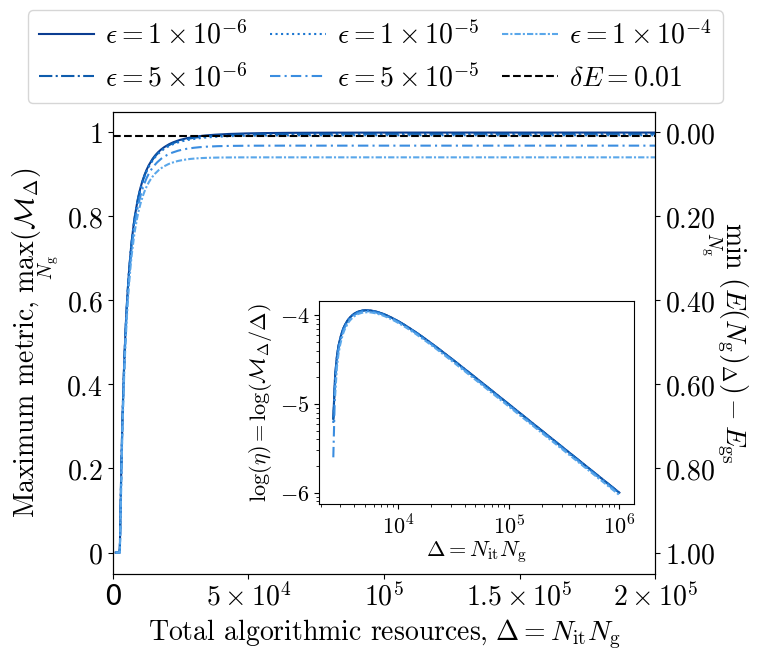

In [91]:
fig, ax1 = plt.subplots(figsize=(7, 6))

blue_shades = ['#0B3D91', '#0E5CAD', '#1B76D1', '#3A8DE0', '#5AA7EA']
line_styles  = ['-', '-.', ':', (0, (5, 2, 1, 2)), (0, (3, 1, 1, 1))]

for idx, (eps, min_metric_per_delta) in enumerate(min_metrics.items()):
    coef, exp = "{:.0e}".format(eps).split("e")
    label = (f"$\\epsilon = {coef}$" if eps == 0
             else f"$\\epsilon = {coef} \\times 10^{{{int(exp)}}}$")
    ax1.plot(D, min_metric_per_delta, label=label,
             color=blue_shades[idx % len(blue_shades)],
             linestyle=line_styles[idx % len(line_styles)])

ax1.axhline(0.99, linestyle='--', color='k', label=r'$\delta E = 0.01$')
ax1.set_xlim([-1, 2e5])
ax1.set_xlabel(r'$\text{Total algorithmic resources,}~\Delta = N_\text{it} N_\text{g}$')
ax1.set_ylabel(r'$\text{Maximum metric,}~\max_{N_\text{g}} (\mathcal{M}_\Delta)$')
ax1.tick_params(axis='y')
ax1.xaxis.set_major_formatter(FuncFormatter(pow10_formatter))
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: rf'${y:g}$'))
ax1.legend(ncol=3, bbox_to_anchor=(1.15, 1.25), columnspacing=0.8, handletextpad=0.4)
#ax1.grid()

ax2 = ax1.twinx()
ax2.set_ylabel(r'$\min_{N_\text{g}}~(E(N_\text{g})_\Delta) - E_\text{gs}$', rotation=270, labelpad=25)
ax2.set_ylim(ax1.get_ylim())
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: rf'${np.abs(1-x):.2f}$'))
ax2.tick_params(axis='y')

inset_ax = ax1.inset_axes([0.38, 0.15, 0.58, 0.44])
for idx, (eps, min_metric_per_delta) in enumerate(min_metrics.items()):
    coef, exp = "{:.0e}".format(eps).split("e")
    ilabel = (f"$\\epsilon = {coef}$" if eps == 0
              else f"$\\epsilon = {coef} \\times 10^{{{int(exp)}}}$")
    eff = np.divide(min_metric_per_delta, D)
    mask = eff > 0                          # ← drop non-positive before log scale
    inset_ax.plot(D[mask], eff[mask], label=ilabel,
                  color=blue_shades[idx % len(blue_shades)],
                  linestyle=line_styles[idx % len(line_styles)])

inset_ax.set_xscale('log')
inset_ax.set_yscale('log')
inset_ax.xaxis.set_major_formatter(FuncFormatter(pow10_formatter))
inset_ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: rf'${int(round(np.log10(y)))}$' if y > 0 else ''))
inset_ax.set_xlabel(r'$\Delta = N_\text{it} N_\text{g}$', fontsize=16, labelpad=0.5)
inset_ax.set_ylabel(r'$\log(\eta) = \log(\mathcal{M}_\Delta / \Delta)$', fontsize=16)
inset_ax.tick_params(axis='both', which='major', labelsize=16)
#inset_ax.grid(True, alpha=0.75)

plt.savefig("../../figures/Error_vs_fixed_resources_with_inset_rya.png", bbox_inches='tight', dpi=300)
plt.show()
